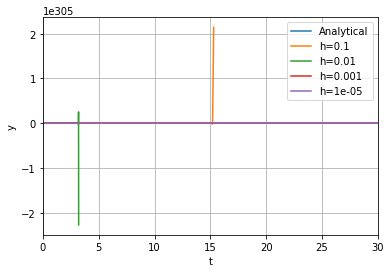

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.seterr(over='ignore', invalid='ignore')

f=lambda t,y:-1000*y+3000-2000*np.exp(-t)
y_exact=lambda t:3-0.998*np.exp(-1000*t)-2.002*np.exp(-t)

def euler(h,t0=0,tf=30,y0=0,m=50000):
    n=int((tf-t0)/h)
    s=max(1,n//m)
    T=[]; Y=[]
    t=t0; y=y0
    for i in range(n+1):
        if i%s==0 or i==n:
            T.append(t); Y.append(y if np.isfinite(y) else np.nan)
        if i<n:
            y=y+h*f(t,y)
            if not np.isfinite(y): break
            t=t+h
    return np.array(T),np.array(Y)

T=np.linspace(0,30,5000)
plt.plot(T,y_exact(T),label='Analytical')

for h in [1e-1,1e-2,1e-3,1e-5]:
    t,y=euler(h)
    plt.plot(t,y,label=f'h={h}')

plt.xlim(0,30)
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()